# 3 &middot; Artificial swaths: tiling and seam edges

Gridded model output sees the whole domain at once; a real satellite only sees a narrow **swath**. To ask *"how much of this feature would a single overpass have caught?"*, `gridfeatures` lays a fixed family of parallel strips over the domain (`swath_index`) and reports which strip each feature sits in and how much of it hugs a strip seam.

This notebook lays swaths across a big elongated feature and checks the seam-edge bookkeeping.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Kilometres per degree (same constant the package uses for its tangent plane).
KM_PER_DEG = math.pi * 6371.0 / 180.0


def add_ellipse(field, lat2d, lon2d, clat, clon, a_deg, b_deg, angle_deg, val):
    """Paint an elliptical blob (value `val`) into `field`.

    `a_deg`/`b_deg` are the semi-axes; longitude offsets are scaled by
    cos(clat) so the blob is round in ground distance, not in raw degrees.
    `angle_deg` tilts the major axis counterclockwise from east.
    """
    th = math.radians(angle_deg)
    dy = lat2d - clat
    dx = (lon2d - clon) * math.cos(math.radians(clat))
    xr = dx * math.cos(th) + dy * math.sin(th)
    yr = -dx * math.sin(th) + dy * math.cos(th)
    field[(xr / a_deg) ** 2 + (yr / b_deg) ** 2 <= 1.0] = val


def fitted_ellipse_lonlat(f, lat0, lon0, n=240):
    """Trace the package's fitted ellipse for feature `f` in lon/lat.

    Uses the public shape stats (major/minor axis km + orientation) and a
    supplied centre, so it draws exactly what `gridfeatures` measured.
    """
    from gridfeatures import stats
    a = stats.major_axis_km(f)
    b = stats.minor_axis_km(f)
    th = math.radians(stats.orientation_deg(f))
    t = np.linspace(0, 2 * np.pi, n)
    xk, yk = (a / 2) * np.cos(t), (b / 2) * np.sin(t)
    xr = xk * math.cos(th) - yk * math.sin(th)
    yr = xk * math.sin(th) + yk * math.cos(th)
    lon = lon0 + xr / (KM_PER_DEG * math.cos(math.radians(lat0)))
    lat = lat0 + yr / KM_PER_DEG
    return lon, lat


## A feature under a family of swaths


In [2]:
from gridfeatures import stats
from gridfeatures.config import Config
from gridfeatures.runner import extract_features
from gridfeatures.swath import swath_index, dominant_swath

res = 0.2
lat = np.arange(0.0, 14.0 + res, res)
lon = np.arange(0.0, 24.0 + res, res)
lats2d, lons2d = np.meshgrid(lat, lon, indexing="ij")

field = np.zeros_like(lats2d)
add_ellipse(field, lats2d, lons2d, clat=7.0, clon=12.0, a_deg=8.0, b_deg=2.5,
            angle_deg=35.0, val=5.0)

WIDTH_KM, ANGLE = 250.0, 70.0
swath = swath_index(lats2d, lons2d, width_km=WIDTH_KM, angle_deg=ANGLE)

cfg = Config(files="mem", variable="x", threshold=1.0, min_size=4,
             statistics={"size": stats.size},
             use_swath=True, swath_width_km=WIDTH_KM, swath_angle_deg=ANGLE)
feats = extract_features(field, lats2d, lons2d, cfg, source="mem", swath=swath)
f = feats[0]

sid, px_in_swath = dominant_swath(f.swath_index)
n_swaths = int(np.unique(f.swath_index).size)
print(f"feature size          : {stats.size(f)} px")
print(f"strips it touches     : {n_swaths}")
print(f"dominant strip id     : {sid}  ({px_in_swath} px in it)")

feature size          : 1581 px
strips it touches     : 6
dominant strip id     : 6  (438 px in it)


## The strips, and the feature draped over them


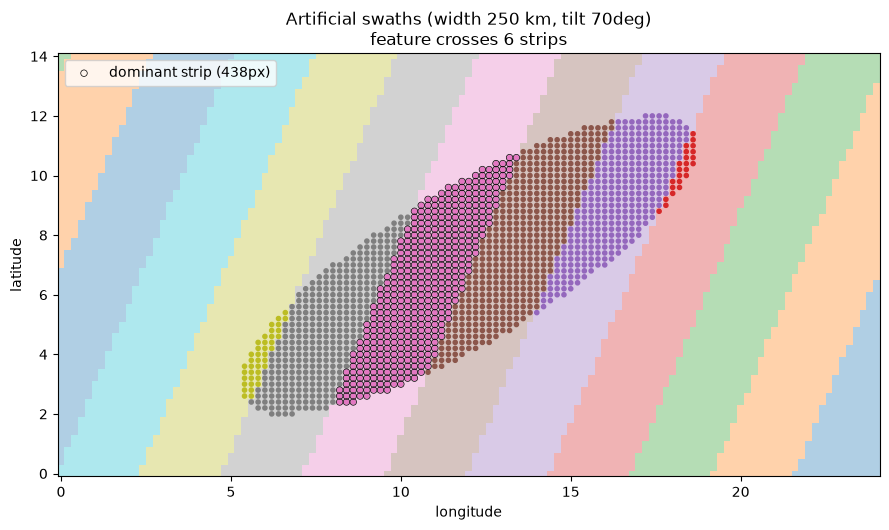

In [3]:
fig, ax = plt.subplots(figsize=(9, 5.4))
mesh = ax.pcolormesh(lon, lat, swath % 10, cmap="tab10", shading="auto", alpha=0.35)

# member cells coloured by their strip
sc = ax.scatter(f.lons, f.lats, c=f.swath_index, cmap="tab10", s=9, vmin=swath.min(), vmax=swath.min()+9)
# highlight the dominant strip
dom = f.swath_index == sid
ax.scatter(f.lons[dom], f.lats[dom], facecolors="none", edgecolors="k", s=22, lw=0.5,
           label=f"dominant strip ({px_in_swath}px)")

ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title(f"Artificial swaths (width {WIDTH_KM:.0f} km, tilt {ANGLE:.0f}deg)\n"
             f"feature crosses {n_swaths} strips")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

## Seam-edge counts

Two different questions:

* `swath_edge_pixels` &mdash; over the **whole** feature, pixels with a neighbour in a different strip. Because it counts *both* sides of every seam, it can exceed the size of any one strip.
* `swath_edge_pixels_in_dominant` &mdash; restricted to the feature's **dominant strip**. This is the one that pairs with `px_in_swath` to form a fraction in [0, 1]: how much of "what one overpass saw" lay against its edge.

In [4]:
whole = stats.swath_edge_pixels(f)
in_dom = stats.swath_edge_pixels_in_dominant(f)
frac = stats.swath_edge_fraction_in_dominant(f)

print(f"swath_edge_pixels (whole feature)   : {whole}")
print(f"swath_edge_pixels_in_dominant       : {in_dom}")
print(f"px_in_swath (dominant strip size)   : {px_in_swath}")
print(f"edge fraction of dominant strip     : {frac:.3f}")
print()

assert in_dom <= px_in_swath, "the dominant-strip edge count is a subset of that strip"
assert 0.0 <= frac <= 1.0,     "so the fraction is always well-defined in [0, 1]"
print("Checks passed: the in-dominant count/fraction is bounded by the strip it lives in,")
print("while the whole-feature count is a different (larger) quantity.")

swath_edge_pixels (whole feature)   : 271
swath_edge_pixels_in_dominant       : 71
px_in_swath (dominant strip size)   : 438
edge fraction of dominant strip     : 0.162

Checks passed: the in-dominant count/fraction is bounded by the strip it lives in,
while the whole-feature count is a different (larger) quantity.
